In [181]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [182]:
df = pd.read_csv("fruits_data.csv")
df.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [183]:
df.shape

(59, 7)

In [184]:
df.columns

Index(['fruit_label', 'fruit_name', 'fruit_subtype', 'mass', 'width', 'height',
       'color_score'],
      dtype='object')

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fruit_label    59 non-null     int64  
 1   fruit_name     59 non-null     object 
 2   fruit_subtype  59 non-null     object 
 3   mass           59 non-null     int64  
 4   width          59 non-null     float64
 5   height         59 non-null     float64
 6   color_score    59 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 3.4+ KB


In [186]:
df.describe()

,fruit_label,mass,width,height,color_score
count,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2.542373,163.118644,7.105085,7.693220,0.762881
std,1.208048,55.018832,0.816938,1.361017,0.076857
min,1.000000,76.000000,5.800000,4.000000,0.550000
25%,1.000000,140.000000,6.600000,7.200000,0.720000
50%,3.000000,158.000000,7.200000,7.600000,0.750000
75%,4.000000,177.000000,7.500000,8.200000,0.810000
max,4.000000,362.000000,9.600000,10.500000,0.930000


In [187]:
df.isnull().sum()

fruit_label      0
fruit_name       0
fruit_subtype    0
mass             0
width            0
height           0
color_score      0
dtype: int64

In [188]:
X = df[['mass', 'width', 'height', 'color_score']]
y = df['fruit_name']

print('Feature Shape:', X.shape)
print('Target Shape:', y.shape)


Feature Shape: (59, 4)
Target Shape: (59,)


In [189]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print('X Train:', X_train.shape)
print('X Test:', X_test.shape)
print('y Train:',y_train.shape)
print('y Test:', y_test.shape)

X Train: (47, 4)
X Test: (12, 4)
y Train: (47,)
y Test: (12,)


In [190]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Scaled Training Shape: (47, 4)
Scaled Testing Shape: (12, 4)


In [191]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [192]:
y_pred = model.predict(X_test_scaled)
print("Predicted Fruits:", y_pred)

print("\n Actual samples:", len(y_test))
print("\n Predicted samples:", len(y_pred))

Predicted Fruits: ['lemon' 'apple' 'lemon' 'apple' 'lemon' 'orange' 'orange' 'orange'
 'orange' 'mandarin' 'apple' 'apple']

 Actual samples: 12

 Predicted samples: 12


In [193]:
print("Actual Fruits:", y_test)

Actual Fruits: 44       lemon
11       apple
54       lemon
15       apple
47       lemon
30      orange
28      orange
41      orange
26      orange
5     mandarin
12       apple
19       apple
Name: fruit_name, dtype: object


In [194]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0


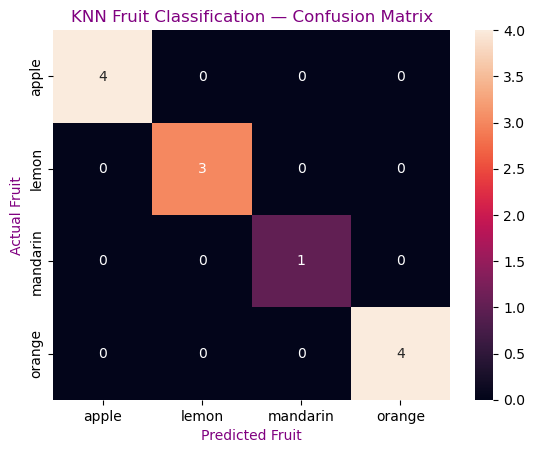

In [197]:
cm = confusion_matrix(y_test, y_pred, labels = model.classes_)

sns.heatmap(cm, annot = True, fmt ="d", xticklabels=model.classes_, yticklabels=model.classes_)

plt.xlabel("Predicted Fruit", color = 'purple')
plt.ylabel("Actual Fruit", color = 'purple')
plt.title("KNN Fruit Classification — Confusion Matrix", color = 'purple')
plt.show()

## Conclusion

In this project, I used the K-Nearest Neighbors (KNN) algorithm to classify fruits based on mass, width, height, and color score.

I split the dataset into training and testing sets and applied StandardScaler to scale the features. The model achieved **100% accuracy on the test set of 12 fruits**.

I also used a confusion matrix to check the predictions for each fruit category.

## Limitations

- The dataset contains only 59 fruit samples.
- The test set contains only 12 samples.
- The model may perform differently on new, unseen fruits.
- Feature scaling is important because KNN uses distances to classify data.